# Quiz 1 - Programming Excercises

## 1. Loss Function

The code below creates data based on a simple linear function $y = 2.3x$, with some outlier elements added to it.

<div class="alert alert-info">
<b>Note:</b> Random number generator between old and new numpy versions might not be the same! In this course we use up-to-date versions. Check that the generated y is the same as what is given in the materials to get reproducable results.
</div>


Matplotlib is building the font cache; this may take a moment.


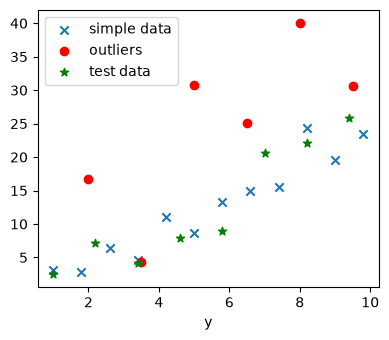

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# set the random seed
np.random.seed(12)

x_easy = np.arange(1, 10, 0.8)
true_coef = 2.3
y_easy = true_coef*x_easy + 1.9*np.random.randn(len(x_easy))

# outliers
x_out = np.arange(2, 10, 1.5)
noise = np.random.randn(len(x_out))
y_out = 4*x_out + 8*noise

# training data
x_train = np.append(x_easy, x_out)
y_train = np.append(y_easy, y_out)


# testing data
np.random.seed(8)
x_test = np.arange(1, 10, 1.2)
y_test = true_coef*x_test + 1.9*np.random.randn(len(x_test))


# plot the data
fsize = (4, 3.5)
plt.figure(figsize=fsize)
plt.scatter(x_easy, y_easy, marker="x", c="tab:blue", label="simple data")
plt.scatter(x_out, y_out, marker="o", c="r", label="outliers")
plt.scatter(x_test, y_test, marker="*", c="g", label="test data")
plt.legend(loc=2)
plt.xlabel("x")
plt.xlabel("y")
plt.tight_layout()
plt.show()


# check numpy version
assert np.allclose(y_easy, np.load("data/quiz1_ex3_ytr.npy")), "Please update your numpy version!"
assert np.allclose(y_out, np.load("data/quiz1_ex3_yout.npy")), "Please update your numpy version!"
assert np.allclose(y_test, np.load("data/quiz1_ex3_ytst.npy")), "Please update your numpy version!"

With this data, consider linear hypothesis space, but five different loss functions, as listed in Table 1. (links to relevant sklearn pages: 
[ridge regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge), [Huber regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.HuberRegressor.html#sklearn.linear_model.HuberRegressor) and [support vector regression](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVR.html#sklearn.svm.LinearSVR)). 


![](img/table_1.png)

Consider always hypotheses going through the origin (i.e. set `fit_intercept=False`), and set the regularisation parameters as given in the Table 1, and with $\epsilon=5$ for the $\epsilon$-insensitive losses.


**Task 1a**: Complete the code below and answer question 3.

In [11]:
from sklearn.linear_model import HuberRegressor, Ridge
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

# TODO: train the models and evaluate their performance on the test data 
# by calculating both the Mean Squared Errors (MSE) and Mean Absolute Errors (MAE).

#Define models
models = {
    "Squared": Ridge(alpha=0.5, fit_intercept=False),
    "Huber": HuberRegressor(alpha=0.5, fit_intercept=False),
    "L1": LinearSVR(loss="epsilon_insensitive", epsilon=0, C=1, dual=True, fit_intercept=False), 
    "Epsilon-insensitive": LinearSVR(loss="epsilon_insensitive", epsilon=5, dual=True, fit_intercept=False),
    "Epsilon_insensitive_squared": LinearSVR(loss="squared_epsilon_insensitive", epsilon=5, dual=False, fit_intercept=False)
}
x_train = x_train.reshape(-1,1)
x_test = x_test.reshape(-1,1)

#Train and evaludate each model
for name, model in models.items():

    # train model
    model.fit(x_train, y_train)

    # predict test data
    y_predict = model.predict(x_test)

    # measure mean squared error
    mse = mean_squared_error(y_test, y_predict)

    # measure mean absolute error
    mae = mean_absolute_error(y_test, y_predict)

    print(f'model name: {model}')

    print("Coefficient", model.coef_)

    print(f'Mean squared error: {mse}')

    print(f'Mean absolute error: {mae}')

    print()

model name: Ridge(alpha=0.5, fit_intercept=False)
Coefficient [2.9472867]
Mean squared error: 17.567300468450874
Mean absolute error: 3.090122617483856

model name: HuberRegressor(alpha=0.5, fit_intercept=False)
Coefficient [2.62534778]
Mean squared error: 11.004948723288427
Mean absolute error: 2.592855928233157

model name: LinearSVR(C=1, dual=True, epsilon=0, fit_intercept=False)
Coefficient [2.3915988]
Mean squared error: 10.734491957018989
Mean absolute error: 2.9639019266638433

model name: LinearSVR(dual=True, epsilon=5, fit_intercept=False)
Coefficient [2.76847763]
Mean squared error: 13.036969843539545
Mean absolute error: 2.5715762942891125

model name: LinearSVR(dual=False, epsilon=5, fit_intercept=False,
          loss='squared_epsilon_insensitive')
Coefficient [3.22506541]
Mean squared error: 28.993469371479627
Mean absolute error: 4.369874034019345



## 2. Breast Cancer Wisconsin

[Breast Cancer Wisconsin](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) is a widely-used dataset, which has the following class distribution as stated in the documentation: *212 - Malignant, 357 - Benign*. 

For this exercise, a subset of features from the dataset has been selected. Download `quiz1_bcw_X.npy` and `quiz1_bcw_y.npy` from the course website. The code below loads the data from the two required files and splits it into training and testing sets.

<div class="alert alert-info">
<b>Note:</b> Random number generator between old an new numpy versions might not be the same!
In this course we use up-to-date versions.
The generated order should be the same as what is given in the materials.
</div>


In [ ]:
import numpy as np
from collections import Counter

# The data provided is a subset given from the sklearn datasets module:
# # from sklearn.datasets import load_breast_cancer
# # X, y = load_breast_cancer(return_X_y=True)
# after this, a subset of features has been taken from X for this exercise - y is exactly as the function returns it
X = np.load("data/quiz1_bcw_X.npy")
y = np.load("data/quiz1_bcw_y.npy")

n = len(y)
print("There are %d samples in total in the dataset" % n)
print("The shape of X:", X.shape)

print("Unique labels in y:", np.unique(y))
print("Counts of labels in y:", Counter(y))


# shuffle the data and randomly divide it to training and testing
# set the random seed
np.random.seed(42)
order = np.random.permutation(n)

# check numpy version
assert np.allclose(order, np.load("data/quiz1_sample_order.npy")), "Please update your numpy version!"


tr_samples = order[:int(0.5*n)]
tst_samples = order[int(0.5*n):]
print("The data is divided into %d training and %d test samples" % (len(tr_samples), len(tst_samples)))
Xtr = X[tr_samples, :]
Xtst = X[tst_samples, :]
ytr = y[tr_samples]
ytst = y[tst_samples]


In [ ]:
def get_classification_labels_from_regression_predictions(unique_labels, y_pred):
    """ Helper function for transforming continuous labels to binary ones
        works with both 0&1 and -1&1 labels
    """
    assert len(unique_labels) == 2  # this function is meant only for binary classification

    meanval = np.mean(unique_labels)

    transformed_predictions = np.zeros(len(y_pred))
    transformed_predictions[y_pred < meanval] = np.min(unique_labels)
    transformed_predictions[y_pred >= meanval] = np.max(unique_labels)

    return transformed_predictions

Train a linear regression model (implement yourself or use [sklearn's LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html), without the intercept term), and a linearSVM imported from sklearn (use [sklearn's linearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC) with settings as given in the template). 
What is the difference between the test accuracies of the model, $accuracy(\mathbf{y}_{true}, \mathbf{y}_{SVM})-accuracy(\mathbf{y}_{true}, \mathbf{y}_{LR})$?

**Task 2a**: Complete the code below and answer question 4.

In [ ]:
from sklearn.svm import LinearSVC

# Linear Regression
# TODO: train a linear regression model 
# (implement yourself or use sklearn’s LinearRegression, without the intercept term),
# and predict on the test data
# ypred_lr = 


# SVM
# use the sklearn's LinearSVM with these settings:
svm = LinearSVC(dual=False)
# TODO: train the svm model, and predict on the test data
# Hint: call svm.fit(...) with suitable arguments in place of ...
# svm.fit(...)
# Hint: call svm.predict(...) with suitable arguments in place of ...
# ypred_svm = svm.predict(...)


# TODO: compute the difference between accuracies



Continuing with the same setting: it is important to catch all the serious cancer cases, while it is not a big deal if some benign cases are predicted as serious. Considering the malignant cases as the "positive" class, what evaluation metric should be used to find which model is better, and which model outperforms the other with respect to this measure? 

**Task 2b**: Complete the code below and answer question 5.

In [ ]:
# TODO: choose a suitable evaluation metric and compare the models


